# 유기동물 입양여부 예측 — Logistic Regression

이 노트북은 유기동물 데이터(`abandoned_animals.xlsx`)를 사용해 **입양여부**(adopted = 1 / not = 0)를
예측하는 **로지스틱 회귀** 모델을 만든다. 핵심 설계는 다음과 같다.

1. **타깃 정의**: `상태 == '종료(입양)'` 이면 1, 그 외 종료 사유는 0. (아직 결과가 안 나온 `보호중` 및 주인에게 돌아간 경우는 제외)
2. **Train/Test 분할**: 0.75 : 0.25, `stratify = 입양여부` (클래스 비율 유지)
3. **텍스트 특징(TF-IDF)**: `특징설명`을 문서로 보고 각 행을 TF-IDF 벡터로 변환 →
   `온순_TFIDF`, `상처_TFIDF`, `백내장_TFIDF`, `사람_TFIDF` 같은 단어별 feature 생성
   - **데이터 누수 방지**: TF-IDF는 **train 에만 `fit`**, test 에는 `transform` 만 적용
   - **과적합 방지**: `min_df=3`, `max_features=500`
4. **개 / 고양이 모델 분리(앙상블 느낌)**: 종이 다르므로 각각 별도 모델을 학습하고,
   전체 test set 예측을 합쳐 최종 성능을 평가
5. **Baseline 2종과 정확도 비교**
   - Baseline 1: **품종(외모)** 만으로 만든 모델
   - Baseline 2: TF-IDF 없이 **특징설명 길이**(길수록 자세하다고 가정)만으로 만든 모델


## 1. 라이브러리 import

In [29]:

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import matplotlib
import matplotlib.pyplot as plt

RANDOM_STATE = 42


## 2. 데이터 로드 & 타깃(입양여부) 정의

`상태` 컬럼의 값 분포는 대략 다음과 같다.

| 상태 | 의미 | 타깃 |
|---|---|---|
| 종료(입양) | 입양됨 | **1** |
| 종료(자연사)/(안락사)/(기증)/(방사) | 입양 아님 | 0 |
| 종료(반환) | 원주인에게 반환 | **제외** |
| 보호중 | 아직 결과 미정 | **제외** |

- `보호중`: 최종 결과가 아직 결정되지 않았으므로 제외한다.
- `종료(반환)`: 원주인에게 돌아간 케이스로, '입양(새 가정을 찾음) vs 그 외' 문제와 성격이 달라 **타깃에서 제외**한다.

(만약 '기증'도 입양에 준하는 것으로 보고 싶다면 아래 타깃 정의를 수정하면 된다.)

In [30]:

DATA_PATH = "abandoned_animals.xlsx"
df = pd.read_excel(DATA_PATH)
print("원본 shape:", df.shape)

# 결과가 미정인 '보호중' + 성격이 다른 '종료(반환)'(원주인 반환) 행 제거
df = df[~df["상태"].isin(["보호중", "종료(반환)"])].copy()

# 이진 타깃 생성: '종료(입양)' 이면 1, 아니면 0
df["입양여부"] = (df["상태"] == "종료(입양)").astype(int)

print("보호중·반환 제거 후 shape:", df.shape)
print("\n입양여부 분포(전체):")
print(df["입양여부"].value_counts())
print("\n동물종류별 입양률:")
print(df.groupby("동물종류")["입양여부"].mean().round(3))


원본 shape: (5161, 14)
보호중·반환 제거 후 shape: (3997, 15)

입양여부 분포(전체):
입양여부
0    2910
1    1087
Name: count, dtype: int64

동물종류별 입양률:
동물종류
개      0.395
고양이    0.180
Name: 입양여부, dtype: float64


## 3. Feature 전처리

원본 컬럼은 문자열로 섞여 있어 모델이 바로 쓸 수 없다. 다음과 같이 정리한다.

- **연령**: `나이`가 `'2016(년생)'` 형태(출생연도) → `기준연도(2025) - 출생연도` 로 나이 계산
- **무게_kg**: `'8.5(Kg)'` 형태 → 숫자만 추출 (`'8..1'` 같은 오타는 첫 유효 숫자만 사용)
- **설명길이**: `특징설명` 문자열 길이 (Baseline 2 에서 사용)
- **품종**: 코드(int)를 문자열 범주로 변환 (One-Hot 인코딩 대상)
- **특징설명**: 결측은 빈 문자열로 채움 (TF-IDF 입력)

In [31]:
REF_YEAR = 2025   # 데이터 기준연도

# 출생연도 4자리를 추출해 나이로 변환
df["연령"] = REF_YEAR - df["나이"].str.extract(r"(\d{4})").astype(float)[0]

# 무게에서 숫자만 추출 (정수/소수 모두 대응, 첫 유효 숫자 사용)
df["무게_kg"] = df["무게"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

# 특징설명 정리 + 길이 feature (Baseline 2 용)
df["특징설명"] = df["특징설명"].fillna("").astype(str)
df["설명길이"] = df["특징설명"].str.len()

# 품종 코드는 범주형이므로 문자열로 변환
df["품종"] = df["품종"].astype(str)

# 전처리 결과 확인
print(df[["동물종류", "품종", "연령", "무게_kg", "성별", "중성화여부", "설명길이", "입양여부"]].head())
print("\n연령/무게 결측 개수:", df["연령"].isna().sum(), "/", df["무게_kg"].isna().sum())


  동물종류   품종   연령  무게_kg 성별 중성화여부  설명길이  입양여부
2    개   89  6.0    5.2  M     Y    56     1
3    개  114  7.0    6.8  M     N    52     1
4    개   72  3.0    2.6  M     N    63     1
6    개  114  4.0   17.0  F     U    62     1
8    개  114  5.0    8.9  M     N    55     0

연령/무게 결측 개수: 0 / 0


## 4. Train / Test 분할 (0.75 : 0.25, stratify = 입양여부)

- 전체 데이터를 한 번 분할해 **하나의 일관된 test set**을 만든다.
- `stratify=y` 로 train/test 의 입양여부 비율을 동일하게 유지한다.
- 이후 개/고양이 모델은 이 분할 안에서 **각 종에 해당하는 부분만** 사용해 학습한다.
  (즉 test set 은 공유하되, 학습은 종별로 따로 진행)

In [32]:
# 모델이 사용할 후보 컬럼들 (각 모델은 이 중 필요한 컬럼만 골라 씀)
feature_cols = ["동물종류", "품종", "연령", "무게_kg", "성별", "중성화여부", "특징설명", "설명길이"]
X = df[feature_cols]
y = df["입양여부"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,            # 75% train / 25% test
    random_state=RANDOM_STATE,
    stratify=y                 # 입양여부 비율 유지
)

print("train:", X_train.shape[0], " / test:", X_test.shape[0])
print("train 입양률: %.3f / test 입양률: %.3f" % (y_train.mean(), y_test.mean()))
print("\n[참고] 다수클래스(전부 '입양 아님') 예측 정확도 =", round(1 - y_test.mean(), 4))


train: 2997  / test: 1000
train 입양률: 0.272 / test 입양률: 0.272

[참고] 다수클래스(전부 '입양 아님') 예측 정확도 = 0.728


## 5. 한국어 TF-IDF 설정

`특징설명`은 `"온순. 얌전. 가슴 상처/출혈. 양 눈 백내장."` 처럼 **마침표(.)·쉼표(,)**로
항목이 구분된다. 따라서 토큰 분리 기준을 다음과 같이 정한다.

- **구분 기준**: `.` 또는 `,` 에서만 분리
- **유지**: 공백(` `)과 슬래시(`/`)는 분리 기준에서 **제외** → 토큰 안에 그대로 남김

예) `"온순. 얌전. 가슴 상처/출혈."` → `['온순', '얌전', '가슴 상처/출혈']`
(즉 `.`/`,` 사이의 한 구절 전체가 하나의 토큰이 된다. 앞뒤 공백만 제거.)

과적합 방지를 위해 `min_df=3`(3개 미만 문서에 나온 토큰 제거), `max_features=500`(상위 500개만 사용)을 설정한다.
**TF-IDF는 train 에만 fit** 되도록 Pipeline 으로 묶어, test 분포를 미리 보는 누수를 원천 차단한다.

> 참고: 구분 기준을 `.`/`,` 로만 두므로 토큰이 단어가 아니라 '구절' 단위가 된다
> (예: `사람 좋아함`, `양 눈 백내장`). 더 세밀한 단어 단위가 필요하면 KoNLPy(Okt/Mecab)를
> `tokenizer` 로 교체하면 된다.

In [33]:
# '.' 또는 ',' 에서만 분리하고, 공백/슬래시는 토큰 안에 그대로 남기는 토크나이저.
def kor_tokenizer(text):
    return [t.strip() for t in re.split(r"[.,]", str(text)) if t.strip()]

# TF-IDF 벡터라이저 팩토리 (매번 새 객체를 만들어 종별로 독립 fit)
def make_tfidf():
    return TfidfVectorizer(
        tokenizer=kor_tokenizer,   # 위에서 정의한 .,기준 토크나이저 사용
        min_df=3,                  # 너무 희귀한 토큰 제거 → 과적합 방지
        max_features=500           # 상위 500개 토큰만 feature 로 사용
    )


## 6. 모델 빌더 정의 (메인 + Baseline 2종)

세 모델 모두 **로지스틱 회귀**이며, 입력 feature 구성만 다르다. `ColumnTransformer` 로 묶으면
`fit` 은 train 에만 적용되므로(특히 TF-IDF의 `fit`) **데이터 누수가 구조적으로 방지**된다.

| 모델 | 사용 feature |
|---|---|
| **메인** | 연령·무게(수치) + 성별·중성화·품종(One-Hot) + **특징설명 TF-IDF** |
| Baseline 1 | **품종** One-Hot 만 |
| Baseline 2 | 메인과 **동일한** 연령·무게·성별·중성화·품종 + **특징설명 길이**(TF-IDF 미사용) |

> Baseline 2 는 메인 모델에서 **TF-IDF 블록만 '설명 길이' 한 개로 바꾼** 모델이다.
> 따라서 메인 vs Baseline 2 비교는 "텍스트를 TF-IDF로 쓰는 것이 단순 길이보다 나은가?"를
> 직접 보는 **ablation** 이 된다.

In [34]:
# ── 메인 모델: 구조적 feature + 특징설명 TF-IDF ──────────────────────────
def build_main_model():
    pre = ColumnTransformer([
        ("num", StandardScaler(), ["연령", "무게_kg"]),                       # 수치형 표준화
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["성별", "중성화여부", "품종"]),  # 범주형 One-Hot
        ("txt", make_tfidf(), "특징설명"),                                    # 텍스트 → TF-IDF (train fit only)
    ])
    return Pipeline([
        ("prep", pre),
        ("clf", LogisticRegression(max_iter=2000)),
    ])

# ── Baseline 1: 품종(외모) 만 ───────────────────────────────────────────
def build_baseline_breed():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["품종"]),
    ])
    return Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=2000))])

# ── Baseline 2: 메인과 동일한 구조 feature + '설명길이' (TF-IDF 대신) ─────
#    메인 모델에서 TF-IDF 블록만 설명길이로 교체한 모델.
def build_baseline_length():
    pre = ColumnTransformer([
        ("num", StandardScaler(), ["연령", "무게_kg", "설명길이"]),                # 메인의 수치형 + 설명길이
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["성별", "중성화여부", "품종"]),  # 메인과 동일한 범주형
    ])
    return Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=2000))])


## 7. 개/고양이 분리 학습

종(개/고양이)마다 별도 모델을 학습한 뒤, 각 종의 test 예측을 **하나의 전체 test set 예측으로 합친다**.
각 instance 는 자기 종 전용 모델이 예측한다.
세 모델(메인/Baseline1/Baseline2) 모두 같은 함수로 평가해 **동일 test set 기준**으로 공정 비교한다.

In [35]:
def train_eval_per_species(build_fn, model_name, store=None):
    '''종별로 모델을 학습하고, 합쳐진 전체 test set 정확도/AUC를 반환.
       store 가 주어지면 학습된 종별 pipeline 을 저장(신규 instance 예측용).'''
    pred = pd.Series(index=X_test.index, dtype=float)   # 합쳐진 예측(클래스)
    proba = pd.Series(index=X_test.index, dtype=float)  # 합쳐진 예측(입양확률)

    for sp in ["개", "고양이"]:
        tr = X_train["동물종류"] == sp     
        te = X_test["동물종류"] == sp        

        pipe = build_fn()
        pipe.fit(X_train[tr], y_train[tr])    # ← fit 은 train 에만 (TF-IDF 포함)

        pred.loc[X_test.index[te]] = pipe.predict(X_test[te])
        proba.loc[X_test.index[te]] = pipe.predict_proba(X_test[te])[:, 1]

        sp_acc = accuracy_score(y_test[te], pipe.predict(X_test[te]))
        print(f"  - {model_name} / {sp}: test 정확도 = {sp_acc:.4f}  (n={te.sum()})")

        if store is not None:
            store[sp] = pipe              # 종별 모델 저장

    acc = accuracy_score(y_test, pred.astype(int))
    auc = roc_auc_score(y_test, proba)
    print(f"  => {model_name} 전체 test 정확도 = {acc:.4f} | AUC = {auc:.4f}\n")
    return {"name": model_name, "accuracy": acc, "auc": auc}


## 8. 세 모델 학습 & 평가

In [36]:
main_models = {}   # 신규 instance 예측에 재사용할 메인 모델(종별) 저장소
results = []

print("■ 메인 모델 (구조 feature + 특징설명 TF-IDF)")
results.append(train_eval_per_species(build_main_model, "메인(TF-IDF)", store=main_models))

print("■ Baseline 1 (품종만)")
results.append(train_eval_per_species(build_baseline_breed, "Baseline1(품종)"))

print("■ Baseline 2 (설명길이만)")
results.append(train_eval_per_species(build_baseline_length, "Baseline2(설명길이)"))


■ 메인 모델 (구조 feature + 특징설명 TF-IDF)
  - 메인(TF-IDF) / 개: test 정확도 = 0.7049  (n=427)
  - 메인(TF-IDF) / 고양이: test 정확도 = 0.8412  (n=573)
  => 메인(TF-IDF) 전체 test 정확도 = 0.7830 | AUC = 0.7942

■ Baseline 1 (품종만)
  - Baseline1(품종) / 개: test 정확도 = 0.6604  (n=427)
  - Baseline1(품종) / 고양이: test 정확도 = 0.8325  (n=573)
  => Baseline1(품종) 전체 test 정확도 = 0.7590 | AUC = 0.7082

■ Baseline 2 (설명길이만)
  - Baseline2(설명길이) / 개: test 정확도 = 0.7002  (n=427)
  - Baseline2(설명길이) / 고양이: test 정확도 = 0.8342  (n=573)
  => Baseline2(설명길이) 전체 test 정확도 = 0.7770 | AUC = 0.7445



  => 메인(TF-IDF) 전체 test 정확도 = 0.7830 | AUC = 0.7942

■ Baseline 1 (품종만)
  - Baseline1(품종) / 개: test 정확도 = 0.6604  (n=427)


  - Baseline1(품종) / 고양이: test 정확도 = 0.8325  (n=573)
  => Baseline1(품종) 전체 test 정확도 = 0.7590 | AUC = 0.7082

■ Baseline 2 (설명길이만)


  - Baseline2(설명길이) / 개: test 정확도 = 0.7002  (n=427)


  - Baseline2(설명길이) / 고양이: test 정확도 = 0.8342  (n=573)
  => Baseline2(설명길이) 전체 test 정확도 = 0.7770 | AUC = 0.7445



## 9. 생성된 TF-IDF 토큰 확인

`.`/`,` 기준으로 분리하므로 토큰은 단어가 아니라 **구절 단위**가 된다
(예: `온순`, `양 눈 백내장`, `사람 좋아함`). 메인 모델이 실제로 만든 토큰을 확인하고,
로지스틱 회귀 계수가 큰(=입양확률에 영향을 준다고 해석할만한 후보군) 토큰도 살펴본다.

In [37]:
# 개 모델의 TF-IDF 토큰과 계수를 추출해 살펴본다.
dog_pipe = main_models["개"]
tfidf = dog_pipe.named_steps["prep"].named_transformers_["txt"]
vocab = tfidf.get_feature_names_out()
print("개 모델 TF-IDF 토큰 개수:", len(vocab))
print("토큰 예시 20개:", list(vocab[:20]))

# 전체 feature 이름 구성 (TF-IDF 토큰에는 _TFIDF 접미사)
prep = dog_pipe.named_steps["prep"]
num_names = ["연령", "무게_kg"]
cat_names = list(prep.named_transformers_["cat"].get_feature_names_out(["성별", "중성화여부", "품종"]))
txt_names = [f"{w}_TFIDF" for w in vocab]
all_names = num_names + cat_names + txt_names

coef = dog_pipe.named_steps["clf"].coef_[0]
coef_s = pd.Series(coef, index=all_names)


tfidf_coef = coef_s[[n for n in all_names if n.endswith("_TFIDF")]].sort_values()
print("\n[개] 음수의 값을 갖는 토큰 Top10:")
print(tfidf_coef.head(10).round(3))
print("\n[개] 양수의 값을 갖는 토큰 Top10:")
print(tfidf_coef.tail(10).round(3))


개 모델 TF-IDF 토큰 개수: 196
토큰 예시 20개: ['가슴 흰 털', '가슴흰털', '갈색 목줄', '겁', '겁 많음', '겁 약간', '겁 약간 있음', '겁 있으나 만지기 가능', '겁 있음', '겁많음', '겁많음/방어적입질', '겁약간/온순', '겁있으나 만지는것가능', '겁있음', '겁있음/만지는건 가능', '겁있음/만지는건 불가', '겁있음/방어적입질', '겁있음/온순/얌전', '겁조금있으나 온순', '결막염']

[개] 음수의 값을 갖는 토큰 Top10:
포유기_TFIDF                   -2.246
예민_TFIDF                    -1.413
서울동물복지지원센터(동대문) 보호중_TFIDF   -1.306
방어적 입질_TFIDF                -1.296
겁있음/만지는건 가능_TFIDF           -1.188
털 변오염_TFIDF                 -1.104
양눈백내장_TFIDF                 -1.099
피부 질환_TFIDF                 -1.058
노령_TFIDF                    -1.042
진드기 오염_TFIDF                -0.986
dtype: float64

[개] 양수의 값을 갖는 토큰 Top10:
웰시코기 혼종 추정_TFIDF     0.894
온순/얌전/사람좋아함_TFIDF    0.954
양눈충혈_TFIDF           0.965
빨간색 목줄_TFIDF         0.970
온순/사람좋아함_TFIDF       0.995
활발_TFIDF             1.015
온순/얌전/사람따름_TFIDF     1.038
꼬리 단미 안됨_TFIDF       1.126
경계/예민/입질_TFIDF       1.393
사람 좋아함_TFIDF         1.573
dtype: float64


           name  accuracy    auc
     메인(TF-IDF)     0.783 0.7942
  Baseline1(품종)     0.759 0.7082
Baseline2(설명길이)     0.777 0.7445
      다수클래스 기준선     0.728 0.5000


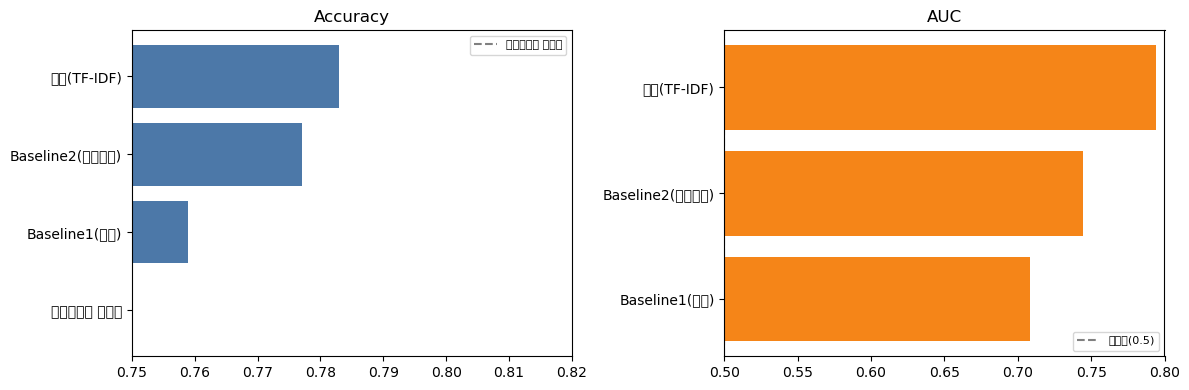

In [38]:
majority_acc = 1 - y_test.mean()

cmp = pd.DataFrame(results)[["name", "accuracy", "auc"]]
cmp = pd.concat([
    cmp,
    pd.DataFrame([{"name": "다수클래스 기준선", "accuracy": majority_acc, "auc": 0.5}])
], ignore_index=True)
cmp["accuracy"] = cmp["accuracy"].round(4)
cmp["auc"] = cmp["auc"].round(4)
print(cmp.to_string(index=False))

# VISUALIZATION----------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

order = cmp.sort_values("accuracy")
ax[0].barh(order["name"], order["accuracy"], color="#4C78A8")
ax[0].axvline(majority_acc, ls="--", color="gray", label="다수클래스 기준선")
ax[0].set_xlim(0.75, 0.82); ax[0].set_title("Accuracy"); ax[0].legend(fontsize=8)

order2 = cmp[cmp["name"] != "다수클래스 기준선"].sort_values("auc")
ax[1].barh(order2["name"], order2["auc"], color="#F58518")
ax[1].axvline(0.5, ls="--", color="gray", label="무작위(0.5)")
ax[1].set_xlim(0.5, 0.8); ax[1].set_title("AUC"); ax[1].legend(fontsize=8)


plt.tight_layout(); plt.show()


In [39]:
# 메인 모델의 상세 분류 리포트 (정밀도/재현율/F1)
all_pred = pd.Series(index=X_test.index, dtype=int)
for sp, pipe in main_models.items():
    te = X_test["동물종류"] == sp
    all_pred.loc[X_test.index[te]] = pipe.predict(X_test[te]).astype(int)

print("메인 모델 분류 리포트 (0=입양아님, 1=입양):")
print(classification_report(y_test, all_pred, target_names=["입양아님", "입양"]))


메인 모델 분류 리포트 (0=입양아님, 1=입양):
              precision    recall  f1-score   support

        입양아님       0.80      0.93      0.86       728
          입양       0.68      0.39      0.49       272

    accuracy                           0.78      1000
   macro avg       0.74      0.66      0.68      1000
weighted avg       0.77      0.78      0.76      1000



## 11. 새로운 instance 의 입양 확률 예측

새 유기동물 정보가 dict 로 들어오면, **동물종류에 맞는 종별 메인 모델**을 골라
동일한 전처리(연령·무게 파싱 → 표준화/One-Hot/TF-IDF transform)를 거쳐 입양 확률을 출력한다.
TF-IDF 는 이미 train 에 fit 된 상태이므로 `transform` 만 수행된다(누수 없음).

In [40]:
def predict_adoption_probability(instance: dict) -> float:
    '''새 instance(dict)의 입양 확률(0~1)을 반환.
       필요한 키: 동물종류, 품종, 나이('2020(년생)' 또는 숫자), 무게('5(Kg)' 또는 숫자),
                 성별(M/F/Q), 중성화여부(Y/N/U), 특징설명(문자열)'''
    species = instance["동물종류"]
    if species not in main_models:
        raise ValueError(f"지원하지 않는 동물종류: {species} (개/고양이만 가능)")

    # 학습 때와 동일한 방식으로 연령/무게 파싱
    age_raw = str(instance.get("나이", ""))
    m = re.search(r"\d{4}", age_raw)
    age = (REF_YEAR - int(m.group())) if m else np.nan

    w_raw = str(instance.get("무게", ""))
    wm = re.search(r"\d+\.?\d*", w_raw)
    weight = float(wm.group()) if wm else np.nan

    row = pd.DataFrame([{
        "연령": age,
        "무게_kg": weight,
        "성별": instance.get("성별", "Q"),
        "중성화여부": instance.get("중성화여부", "U"),
        "품종": str(instance.get("품종", "")),
        "특징설명": str(instance.get("특징설명", "")),
    }])

    pipe = main_models[species]                 # 종별 모델 선택
    return float(pipe.predict_proba(row)[:, 1][0])


# ── 데모: 예시 instance 2개 ──────────────────────────────────────────
demo_good = {
    "동물종류": "개", "품종": "000114", "나이": "2023(년생)", "무게": "5(Kg)",
    "성별": "M", "중성화여부": "Y",
    "특징설명": "온순. 활발. 사람 좋아함. 잘 따름. 털 상태 양호.",
}
demo_bad = {
    "동물종류": "개", "품종": "000114", "나이": "2011(년생)", "무게": "6(Kg)",
    "성별": "F", "중성화여부": "U",
    "특징설명": "사나움. 경계. 양 눈 백내장. 상처. 피부 질환. 잘 걷지 못함.",
}

print("예시1(온순/젊음) 입양 확률 : %.1f%%" % (predict_adoption_probability(demo_good) * 100))
print("예시2(경계/노령/질환) 입양 확률 : %.1f%%" % (predict_adoption_probability(demo_bad) * 100))


예시1(온순/젊음) 입양 확률 : 92.2%
예시2(경계/노령/질환) 입양 확률 : 18.6%
